In [1]:
import pandas as pd
import numpy as np

In [2]:
metadata = pd.read_csv("metadata.csv")

metadata.head()

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


In [3]:
discharge_df = metadata[metadata["type"] == "discharge"]

print("Total discharge cycles:", len(discharge_df))
discharge_df.head()

Total discharge cycles: 2794


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN
6,discharge,[2.010e+03 7.000e+00 2.200e+01 1.000e+00 4.000...,4,B0047,6,7,00007.csv,1.5080762969973425,NaN,NaN
8,discharge,[2010. 7. 22. 6. 16. ...,4,B0047,8,9,00009.csv,1.4835577960067696,NaN,NaN
10,discharge,[2010. 7. 22. 10. 51. ...,4,B0047,10,11,00011.csv,1.4671391666146525,NaN,NaN


In [4]:
print("Unique Batteries:")
print(discharge_df["battery_id"].unique())

Unique Batteries:
<StringArray>
['B0047', 'B0045', 'B0048', 'B0046', 'B0043', 'B0032', 'B0039', 'B0040',
 'B0029', 'B0028', 'B0042', 'B0034', 'B0038', 'B0033', 'B0030', 'B0041',
 'B0027', 'B0044', 'B0036', 'B0025', 'B0026', 'B0031', 'B0049', 'B0050',
 'B0052', 'B0051', 'B0006', 'B0005', 'B0007', 'B0018', 'B0053', 'B0054',
 'B0056', 'B0055']
Length: 34, dtype: str


In [5]:
battery_id = "B0047"

battery_df = discharge_df[discharge_df["battery_id"] == battery_id]

print("Total discharge cycles for", battery_id, ":", len(battery_df))

battery_df.head()

Total discharge cycles for B0047 : 72


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN
6,discharge,[2.010e+03 7.000e+00 2.200e+01 1.000e+00 4.000...,4,B0047,6,7,00007.csv,1.5080762969973425,NaN,NaN
8,discharge,[2010. 7. 22. 6. 16. ...,4,B0047,8,9,00009.csv,1.4835577960067696,NaN,NaN
10,discharge,[2010. 7. 22. 10. 51. ...,4,B0047,10,11,00011.csv,1.4671391666146525,NaN,NaN


In [6]:
cycle_numbers = []
capacities = []
avg_temperatures = []
discharge_durations = []

In [7]:
for index, row in battery_df.iterrows():
    
    filename = row["filename"]
    capacity = row["Capacity"]
    
    # Load cycle file
    cycle_data = pd.read_csv("data/" + filename)
    
    # Calculate average temperature
    avg_temp = cycle_data["Temperature_measured"].mean()
    
    # Calculate discharge duration
    duration = cycle_data["Time"].max()
    
    # Store values
    cycle_numbers.append(len(cycle_numbers) + 1)
    capacities.append(capacity)
    avg_temperatures.append(avg_temp)
    discharge_durations.append(duration)

In [8]:
cycle_features_df = pd.DataFrame({
    "cycle_number": cycle_numbers,
    "capacity": capacities,
    "avg_temperature": avg_temperatures,
    "discharge_duration": discharge_durations
})

cycle_features_df.head()

,cycle_number,capacity,avg_temperature,discharge_duration
0,1,1.6743047446975208,8.272423,6436.141
1,2,1.5243662105099023,8.210715,5650.265
2,3,1.5080762969973425,7.954455,5590.907
3,4,1.4835577960067696,7.985865,5543.610
4,5,1.4671391666146525,8.009427,5499.046


In [9]:
initial_capacity = cycle_features_df["capacity"].iloc[0]

cycle_features_df["capacity_fade"] = initial_capacity - cycle_features_df["capacity"]

cycle_features_df["capacity_retention_percent"] = (
    cycle_features_df["capacity"] / initial_capacity
) * 100

cycle_features_df.head()

TypeError: unsupported operand type(s) for -: 'str' and 'str'

In [10]:
cycle_features_df["capacity"] = pd.to_numeric(
    cycle_features_df["capacity"],
    errors="coerce"
)

cycle_features_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cycle_number        72 non-null     int64  
 1   capacity            72 non-null     float64
 2   avg_temperature     72 non-null     float64
 3   discharge_duration  72 non-null     float64
dtypes: float64(3), int64(1)
memory usage: 2.4 KB


In [11]:
initial_capacity = cycle_features_df["capacity"].iloc[0]

cycle_features_df["capacity_fade"] = initial_capacity - cycle_features_df["capacity"]

cycle_features_df["capacity_retention_percent"] = (
    cycle_features_df["capacity"] / initial_capacity
) * 100

cycle_features_df.head()

,cycle_number,capacity,avg_temperature,discharge_duration,capacity_fade,capacity_retention_percent
0,1,1.674305,8.272423,6436.141,0.000000,100.000000
1,2,1.524366,8.210715,5650.265,0.149939,91.044729
2,3,1.508076,7.954455,5590.907,0.166228,90.071793
3,4,1.483558,7.985865,5543.610,0.190747,88.607394
4,5,1.467139,8.009427,5499.046,0.207166,87.626770


In [12]:
def classify_stress(retention):
    if retention > 85:
        return "Low"
    elif retention >= 75:
        return "Medium"
    else:
        return "High"

cycle_features_df["stress_risk"] = cycle_features_df["capacity_retention_percent"].apply(classify_stress)

cycle_features_df.head()

,cycle_number,capacity,avg_temperature,discharge_duration,capacity_fade,capacity_retention_percent,stress_risk
0,1,1.674305,8.272423,6436.141,0.000000,100.000000,Low
1,2,1.524366,8.210715,5650.265,0.149939,91.044729,Low
2,3,1.508076,7.954455,5590.907,0.166228,90.071793,Low
3,4,1.483558,7.985865,5543.610,0.190747,88.607394,Low
4,5,1.467139,8.009427,5499.046,0.207166,87.626770,Low


In [13]:
cycle_features_df["stress_risk"].value_counts()

stress_risk
High      46
Medium    18
Low        8
Name: count, dtype: int64

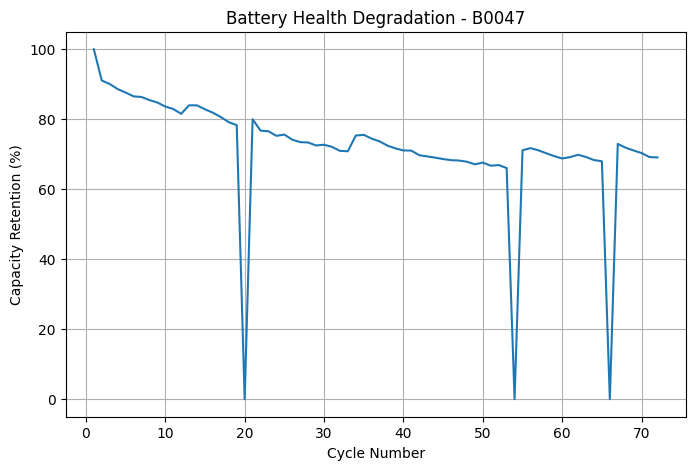

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(cycle_features_df["cycle_number"],
         cycle_features_df["capacity_retention_percent"])

plt.xlabel("Cycle Number")
plt.ylabel("Capacity Retention (%)")
plt.title("Battery Health Degradation - B0047")

plt.grid(True)
plt.show()

In [15]:
cycle_features_df = cycle_features_df[
    cycle_features_df["capacity_retention_percent"] > 0
]

cycle_features_df.reset_index(drop=True, inplace=True)

cycle_features_df.head()

,cycle_number,capacity,avg_temperature,discharge_duration,capacity_fade,capacity_retention_percent,stress_risk
0,1,1.674305,8.272423,6436.141,0.000000,100.000000,Low
1,2,1.524366,8.210715,5650.265,0.149939,91.044729,Low
2,3,1.508076,7.954455,5590.907,0.166228,90.071793,Low
3,4,1.483558,7.985865,5543.610,0.190747,88.607394,Low
4,5,1.467139,8.009427,5499.046,0.207166,87.626770,Low


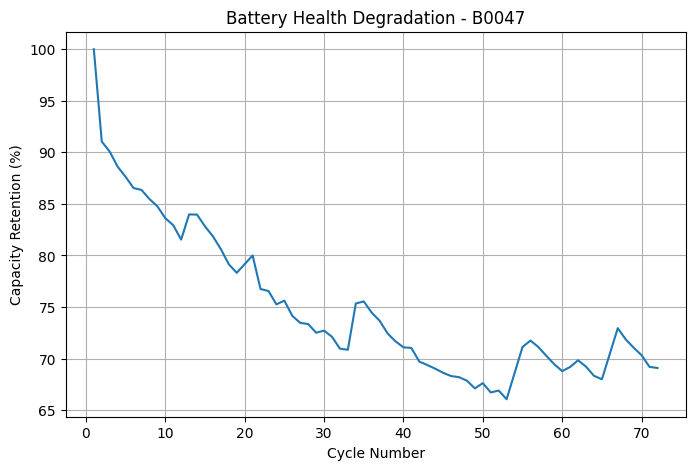

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(cycle_features_df["cycle_number"],
         cycle_features_df["capacity_retention_percent"])

plt.xlabel("Cycle Number")
plt.ylabel("Capacity Retention (%)")
plt.title("Battery Health Degradation - B0047")

plt.grid(True)
plt.show()

In [17]:
def health_alert(retention):
    if retention > 85:
        return "Healthy"
    elif retention > 80:
        return "Warning"
    elif retention > 75:
        return "Critical Warning"
    else:
        return "High Risk"

cycle_features_df["health_alert"] = cycle_features_df["capacity_retention_percent"].apply(health_alert)

cycle_features_df.head()

,cycle_number,capacity,avg_temperature,discharge_duration,capacity_fade,capacity_retention_percent,stress_risk,health_alert
0,1,1.674305,8.272423,6436.141,0.000000,100.000000,Low,Healthy
1,2,1.524366,8.210715,5650.265,0.149939,91.044729,Low,Healthy
2,3,1.508076,7.954455,5590.907,0.166228,90.071793,Low,Healthy
3,4,1.483558,7.985865,5543.610,0.190747,88.607394,Low,Healthy
4,5,1.467139,8.009427,5499.046,0.207166,87.626770,Low,Healthy


In [18]:
cycle_features_df["degradation_rate_per_cycle"] = (
    cycle_features_df["capacity_retention_percent"].diff()
)

cycle_features_df.head()

,cycle_number,capacity,avg_temperature,discharge_duration,capacity_fade,capacity_retention_percent,stress_risk,health_alert,degradation_rate_per_cycle
0,1,1.674305,8.272423,6436.141,0.000000,100.000000,Low,Healthy,NaN
1,2,1.524366,8.210715,5650.265,0.149939,91.044729,Low,Healthy,-8.955271
2,3,1.508076,7.954455,5590.907,0.166228,90.071793,Low,Healthy,-0.972936
3,4,1.483558,7.985865,5543.610,0.190747,88.607394,Low,Healthy,-1.464399
4,5,1.467139,8.009427,5499.046,0.207166,87.626770,Low,Healthy,-0.980624


In [19]:
average_degradation = cycle_features_df["degradation_rate_per_cycle"].mean()

print("Average degradation per cycle:", average_degradation)

Average degradation per cycle: -0.4546188980061145


In [20]:
below_80 = cycle_features_df[
    cycle_features_df["capacity_retention_percent"] < 80
]

first_below_80_cycle = below_80["cycle_number"].iloc[0]

print("Battery crossed 80% health at cycle:", first_below_80_cycle)

Battery crossed 80% health at cycle: 18


In [21]:
current_health = cycle_features_df["capacity_retention_percent"].iloc[-1]

target_health = 60

avg_deg = abs(average_degradation)

remaining_cycles = (current_health - target_health) / avg_deg

predicted_total_cycles = cycle_features_df["cycle_number"].iloc[-1] + remaining_cycles

print("Current Health:", current_health)
print("Estimated Remaining Cycles until 60%:", round(remaining_cycles))
print("Predicted Total Life Cycles:", round(predicted_total_cycles))

Current Health: 69.08591493558421
Estimated Remaining Cycles until 60%: 20
Predicted Total Life Cycles: 92


In [22]:
def user_summary(current_health, remaining_cycles):
    
    if current_health > 85:
        status = "🟢 Excellent"
        message = "Your battery is in excellent condition."
    
    elif current_health > 75:
        status = "🟡 Good"
        message = "Battery is healthy but starting to degrade."
    
    elif current_health > 65:
        status = "🟠 Warning"
        message = "Battery performance is dropping. Monitor usage."
    
    else:
        status = "🔴 Critical"
        message = "Battery health is low. Consider replacement soon."
    
    if remaining_cycles > 30:
        urgency = "No immediate action required."
    elif remaining_cycles > 10:
        urgency = "Plan battery check within next few weeks."
    else:
        urgency = "Replacement may be required soon."
    
    return status, message, urgency


status, message, urgency = user_summary(current_health, remaining_cycles)

print("========= BATTERY HEALTH REPORT =========")
print("Current Health:", round(current_health,2), "%")
print("Status:", status)
print("Message:", message)
print("Estimated Remaining Cycles:", round(remaining_cycles))
print("Advice:", urgency)

========= BATTERY HEALTH REPORT =========
Current Health: 69.09 %
Status: 🟠 Warning
Message: Battery performance is dropping. Monitor usage.
Estimated Remaining Cycles: 20
Advice: Plan battery check within next few weeks.


In [23]:
battery_score = round(current_health)
print("Battery Score:", battery_score, "/ 100")

Battery Score: 69 / 100


In [24]:
avg_cycles_per_week = 5
weeks_left = remaining_cycles / avg_cycles_per_week

print("Approx weeks left:", round(weeks_left))

Approx weeks left: 4


In [25]:
cycle_features_df.to_csv("battery_iq_engineered_dataset.csv", index=False)
print("Engineered dataset saved.")

Engineered dataset saved.


In [26]:
from battery_core_engine import analyze_battery

result = analyze_battery(uploaded_dataframe)

ModuleNotFoundError: No module named 'battery_core_engine'